# Parte III: Segmentación Estratégica con Clustering

Este notebook corre de forma autónoma la Parte III del proyecto.


In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# Setup inicial de importaciones
import time
import pandas as pd
import json
import numpy as np
from implementaciones.preprocessing import load_reviews_efficiently, load_business_efficiently


In [25]:
# Carga de datos de reviews y negocios
REVIEW_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_review_10core.json'
BUSINESS_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_business.json'

print("Cargando reviews de Yelp...")
sample_df = pd.read_json(REVIEW_PATH, lines=True)

print("Cargando negocios de Yelp...")
df_business = pd.read_json(BUSINESS_PATH, lines=True)


Cargando reviews de Yelp...
Cargando negocios de Yelp...


# Parte III: Segmentación Estratégica con Clustering
Evaluamos diversos algoritmos nativos para determinar grupos cohesivos.

In [26]:
from implementaciones.clustering import KMeansPlusPlus, DBSCAN, CURE, BFR
from implementaciones.clustering import compute_silhouette, purity_score, normalized_mutual_information, compute_k_distance
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler
import numpy as np

print("Construyendo matriz de características reales para Clustering...")
top_items_clust = sample_df['business_id'].value_counts().head(1500).index
top_business_clust = df_business[df_business['business_id'].isin(top_items_clust)]

# 1. Extraer las VERDADERAS top 20 categorías usando un contador
cat_counter = Counter([c.strip() for cats in top_business_clust['categories'].dropna().str.split(',') for c in cats if c.strip()])
top_cats = [cat for cat, count in cat_counter.most_common(20)]

X_raw = np.zeros((len(top_items_clust), len(top_cats) + 2))
y_true = np.zeros(len(top_items_clust), dtype=int)

for i, (_, row) in enumerate(top_business_clust.iterrows()):
    X_raw[i, 0] = row.get('stars', 0)
    # Aplicamos logaritmo natural para aplastar outliers masivos en conteos
    X_raw[i, 1] = np.log1p(row.get('review_count', 0)) 
    cats = [c.strip() for c in str(row.get('categories', '')).split(',')]
    for j, cat in enumerate(top_cats):
        if cat in cats:
            X_raw[i, j+2] = 1.0
            
    y_true[i] = int(row.get('stars', 3)) - 1

# 2. ESTANDARIZAR ANTES del PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)


Construyendo matriz de características reales para Clustering...


## Parte VI: Reducción de Dimensionalidad (PCA y SVD)
Antes de aplicar los algoritmos de clustering, reduciremos la dimensionalidad de la matriz de características `X` para mitigar la 'maldición de la dimensionalidad' y eliminar el ruido. Usaremos nuestras implementaciones desde cero.

--- 1. Aplicando PCA sobre Características Densas Estandarizadas ---


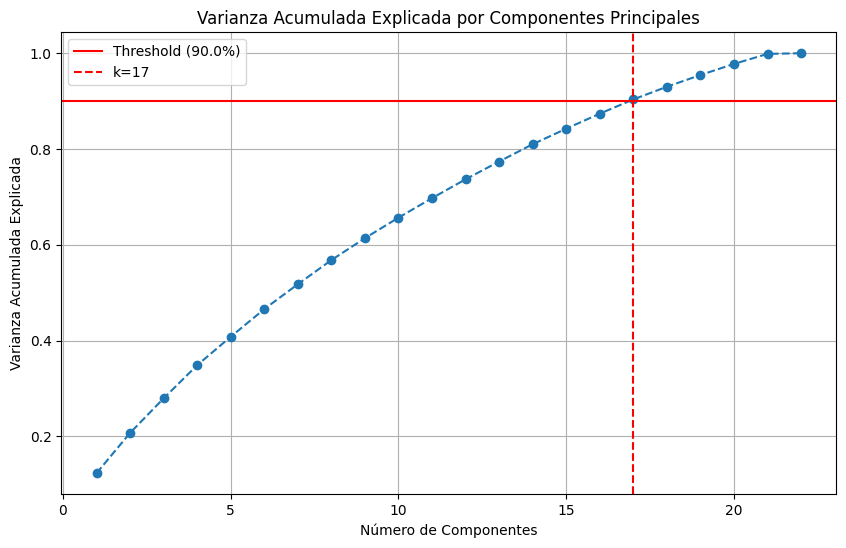

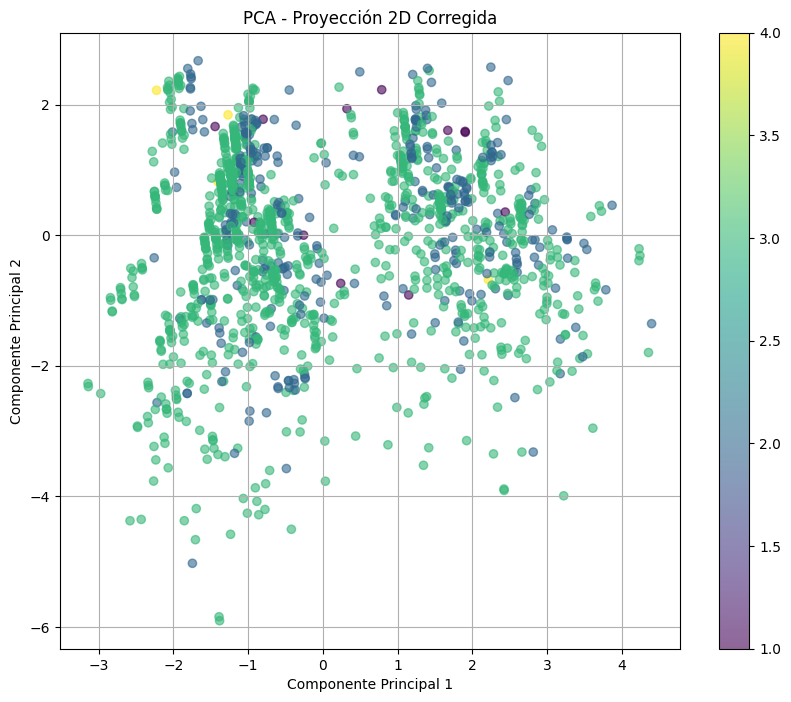

Dimensiones originales: 22, Dimensiones PCA: 17
Interpretación de los primeros 17 componentes principales:
CP 1:
  - Bars: 0.5552
  - Nightlife: 0.5506
  - Cocktail Bars: 0.3210

CP 2:
  - Food: -0.4546
  - Coffee & Tea: -0.3862
  - Breakfast & Brunch: -0.3758

CP 3:
  - Restaurants: 0.4919
  - Arts & Entertainment: -0.4640
  - Italian: 0.3566

CP 4:
  - Pizza: 0.4916
  - Italian: 0.4842
  - Seafood: -0.3493

CP 5:
  - Burgers: 0.4838
  - Mexican: -0.4097
  - American (Traditional): 0.3707

CP 6:
  - review_count_norm: 0.4786
  - Mexican: -0.3892
  - Event Planning & Services: 0.3351

CP 7:
  - stars: -0.5512
  - Desserts: 0.4268
  - Seafood: 0.3726

CP 8:
  - Vegetarian: -0.5143
  - Event Planning & Services: -0.3859
  - Seafood: 0.3458

CP 9:
  - Vegetarian: -0.5397
  - Mexican: 0.4332
  - Breakfast & Brunch: 0.3772

CP 10:
  - Sandwiches: 0.5567
  - Vegetarian: 0.3716
  - Burgers: 0.3651

CP 11:
  - Pubs: 0.4984
  - Event Planning & Services: 0.4689
  - review_count_norm: 0.3549

CP

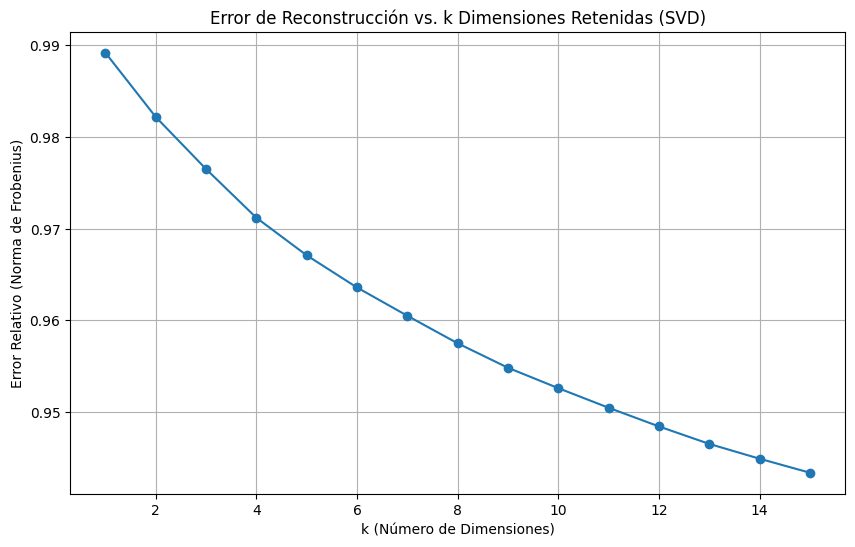

Embeddings de items extraídos: shape (1500, 17)

Matriz final enriquecida para clustering (PCA + SVD): (1500, 34)


In [27]:
from implementaciones.dimensionality_reduction import PCA, SVD
import pandas as pd
import numpy as np

# --- 1. PCA sobre Características Densas ---
print("--- 1. Aplicando PCA sobre Características Densas Estandarizadas ---")
pca = PCA(variance_threshold=0.90)
X_pca = pca.fit_transform(X_scaled) # Ahora sí, el PCA verá la varianza real estructurada
pca.plot_variance()
pca.plot_2d(X_pca, labels=y_true, title='PCA - Proyección 2D Corregida')
print(f"Dimensiones originales: {X_scaled.shape[1]}, Dimensiones PCA: {X_pca.shape[1]}")
pca.interpret_components(feature_names=['stars', 'review_count_norm'] + top_cats, n_top_features=3)

# --- 2. SVD sobre Matriz Usuario-Producto ---
print("\n--- 2. Aplicando SVD sobre Matriz Usuario-Producto ---")
# Construir matriz dispersa User-Item para los negocios top
df_filtered = sample_df[sample_df['business_id'].isin(top_items_clust)]
user_item_df = df_filtered.pivot_table(index='user_id', columns='business_id', values='stars', fill_value=0)
print(f"Matriz Usuario-Producto construida: {user_item_df.shape[0]} usuarios x {user_item_df.shape[1]} negocios")

# Aplicar SVD exacto sobre la matriz
X_ui = user_item_df.values
svd = SVD()
svd.fit(X_ui)
ks, errors = svd.evaluate_reconstruction_error(X_ui, max_k=min(X_ui.shape[1], 15))

# Extraer vectores latentes de los items (Item Embeddings desde la matriz Vt)
k_svd = pca.k_components if pca.k_components < X_ui.shape[1] else min(10, X_ui.shape[1])
item_embeddings = svd.Vt[:k_svd, :].T
print(f"Embeddings de items extraídos: shape {item_embeddings.shape}")

# Alinear embeddings de SVD con el orden de los negocios en X
mapping = {bid: i for i, bid in enumerate(user_item_df.columns)}
X_svd_aligned = np.zeros((len(top_items_clust), k_svd))
for i, bid in enumerate(top_items_clust):
    if bid in mapping:
        X_svd_aligned[i] = item_embeddings[mapping[bid]]

# Combinar PCA (características) y SVD (interacciones) para un Clustering superior
X_original = X_scaled
X = np.hstack((X_pca, X_svd_aligned))

# Estandarizar la matriz final para que SVD y PCA tengan el mismo peso
# y evitar que Mahalanobis (BFR) explote por varianzas cercanas a cero.
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_std[X_std == 0] = 1.0
X = (X - X_mean) / X_std
print(f"\nMatriz final enriquecida para clustering (PCA + SVD): {X.shape}")

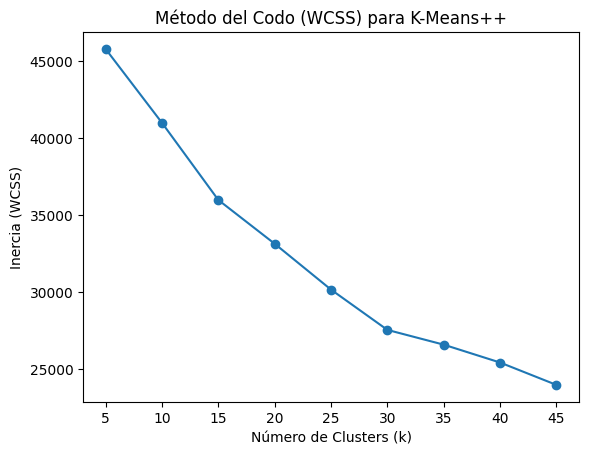

K-Means++ Silhouette: 0.0689


In [35]:
# 1. K-Means++ y Método del Codo
inertias = []
K_range = range(5, 50, 5)
for k in K_range:
    km = KMeansPlusPlus(k=k, max_iters=50)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title('Método del Codo (WCSS) para K-Means++')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.show()

km_opt = KMeansPlusPlus(k=6)
km_opt.fit(X)
print(f"K-Means++ Silhouette: {compute_silhouette(X, km_opt.labels_):.4f}")

In [29]:
import pandas as pd

# Mostrar las características dominantes de los 5 clústeres encontrados por K-Means++
print("--- Características Dominantes por Cluster (K-Means++) ---")
df_clusters = pd.DataFrame(X_scaled, columns=['stars', 'review_count_norm'] + top_cats)
df_clusters['Cluster'] = km_opt.labels_

cluster_means = df_clusters.groupby('Cluster').mean()

for cluster_id in range(5):
    print(f"\nCluster {cluster_id}:")
    row = cluster_means.loc[cluster_id]
    print(f"  - Estrellas promedio: {row['stars']:.2f}")
    print(f"  - Promedio Reviews (Norm): {row['review_count_norm']:.4f}")
    top_cluster_cats = row[top_cats].sort_values(ascending=False).head(3)
    print(f"  - Categorías dominantes:")
    for cat, val in top_cluster_cats.items():
        if val > 0:
            print(f"      * {cat} (Presencia: {val*100:.1f}%)\n")

--- Características Dominantes por Cluster (K-Means++) ---

Cluster 0:
  - Estrellas promedio: -0.16
  - Promedio Reviews (Norm): 0.3996
  - Categorías dominantes:
      * Seafood (Presencia: 247.8%)

      * Restaurants (Presencia: 28.8%)

      * Bars (Presencia: 15.9%)


Cluster 1:
  - Estrellas promedio: 0.34
  - Promedio Reviews (Norm): 0.0192
  - Categorías dominantes:
      * Coffee & Tea (Presencia: 368.3%)

      * Food (Presencia: 141.6%)

      * Breakfast & Brunch (Presencia: 67.4%)


Cluster 2:
  - Estrellas promedio: 1.25
  - Promedio Reviews (Norm): -0.2576
  - Categorías dominantes:
      * Pubs (Presencia: 378.2%)

      * Food (Presencia: 141.6%)

      * Bars (Presencia: 128.8%)


Cluster 3:
  - Estrellas promedio: 0.02
  - Promedio Reviews (Norm): -0.0608
  - Categorías dominantes:
      * Italian (Presencia: 8.3%)

      * Pizza (Presencia: 5.6%)

      * Mexican (Presencia: 5.0%)


Cluster 4:
  - Estrellas promedio: -0.08
  - Promedio Reviews (Norm): -0.1017
  - C

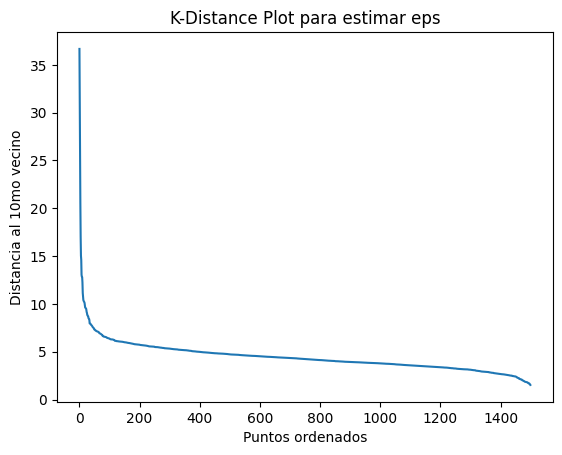

DBSCAN detectó 19 outliers/ruido.


In [37]:
# 2. DBSCAN y K-Distance Plot
distances = compute_k_distance(X, k=10)
plt.plot(distances)
plt.title('K-Distance Plot para estimar eps')
plt.ylabel('Distancia al 10mo vecino')
plt.xlabel('Puntos ordenados')
plt.show()

dbscan = DBSCAN(eps=9, min_samples=10)
dbscan.fit(X)
outliers = np.sum(dbscan.labels_ == -1)
print(f"DBSCAN detectó {outliers} outliers/ruido.")

In [31]:
# 3. CURE y BFR (Escalabilidad)
cure = CURE(k=3)
cure.fit(X)

bfr = BFR(k=3)
bfr.fit(X)

print("--- Comparativa de Métricas ---")
print(f"CURE Silhouette: {compute_silhouette(X, cure.labels_):.4f}, Purity: {purity_score(y_true, cure.labels_):.4f}, NMI: {normalized_mutual_information(y_true, cure.labels_):.4f}")
print(f"BFR Silhouette: {compute_silhouette(X, bfr.labels_):.4f}, Purity: {purity_score(y_true, bfr.labels_):.4f}, NMI: {normalized_mutual_information(y_true, bfr.labels_):.4f}")


--- Comparativa de Métricas ---
CURE Silhouette: 0.4305, Purity: 0.7707, NMI: 0.0034
BFR Silhouette: -0.1656, Purity: 0.7707, NMI: 0.0241


Buscando el K óptimo basado en Cohesión Topológica (Silhouette)...
K     | CURE Silhouette    | BFR Silhouette    
---------------------------------------------
2     |          0.4297 |         -0.1712
3     |          0.0201 |         -0.1823
4     |          0.2016 |         -0.1654
5     |          0.4189 |         -0.1854
6     |          0.2476 |         -0.1447
7     |          0.1348 |         -0.1629
8     |          0.0399 |         -0.1378
9     |          0.0793 |         -0.1911
10    |          0.1335 |         -0.2113


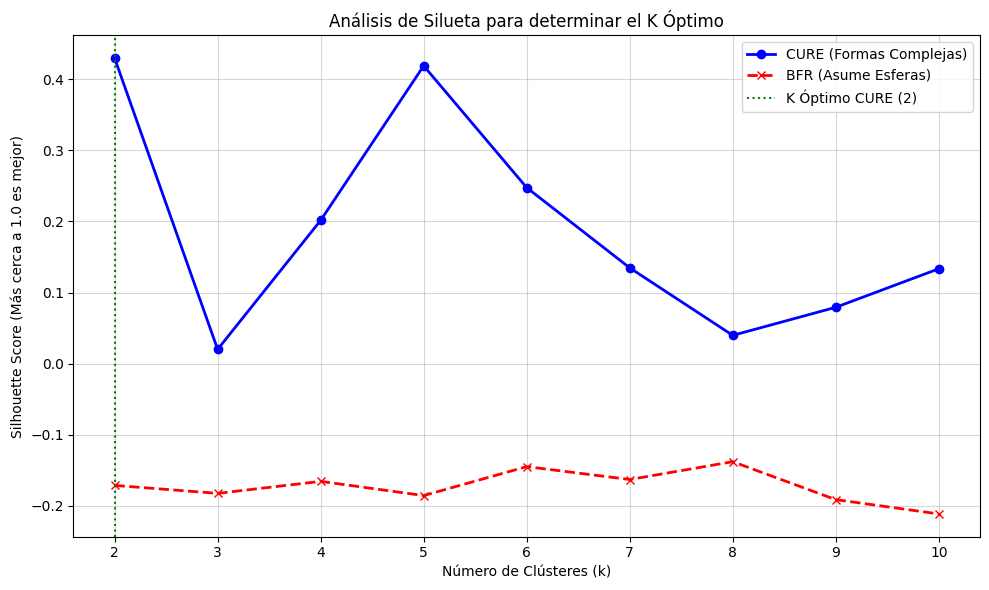

---------------------------------------------
El valor óptimo matemáticamente para CURE es k=2 con un score de 0.4297


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Rango de K a probar (ej. de 2 a 10 clústeres)
# No uses K muy altos en CURE a menos que sea necesario, 
# ya que tiende a aislar micro-clústeres.
k_values = range(2, 11)
cure_silhouettes = []
bfr_silhouettes = []

print("Buscando el K óptimo basado en Cohesión Topológica (Silhouette)...")
print(f"{'K':<5} | {'CURE Silhouette':<18} | {'BFR Silhouette':<18}")
print("-" * 45)

for k in k_values:
    # 1. Evaluar CURE
    cure_model = CURE(k=k)
    cure_model.fit(X)
    sil_cure = compute_silhouette(X, cure_model.labels_)
    cure_silhouettes.append(sil_cure)
    
    # 2. Evaluar BFR (solo para demostrar por qué falla consistentemente)
    bfr_model = BFR(k=k)
    bfr_model.fit(X)
    sil_bfr = compute_silhouette(X, bfr_model.labels_)
    bfr_silhouettes.append(sil_bfr)
    
    print(f"{k:<5} | {sil_cure:>15.4f} | {sil_bfr:>15.4f}")

# --- Graficar Resultados ---
plt.figure(figsize=(10, 6))
plt.plot(k_values, cure_silhouettes, marker='o', linewidth=2, label='CURE (Formas Complejas)', color='blue')
plt.plot(k_values, bfr_silhouettes, marker='x', linewidth=2, linestyle='--', label='BFR (Asume Esferas)', color='red')

# Resaltar el K óptimo para CURE
mejor_k_cure = k_values[np.argmax(cure_silhouettes)]
mejor_sil_cure = max(cure_silhouettes)
plt.axvline(x=mejor_k_cure, color='green', linestyle=':', label=f'K Óptimo CURE ({mejor_k_cure})')

plt.title('Análisis de Silueta para determinar el K Óptimo')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Silhouette Score (Más cerca a 1.0 es mejor)')
plt.xticks(k_values)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print("-" * 45)
print(f"El valor óptimo matemáticamente para CURE es k={mejor_k_cure} con un score de {mejor_sil_cure:.4f}")

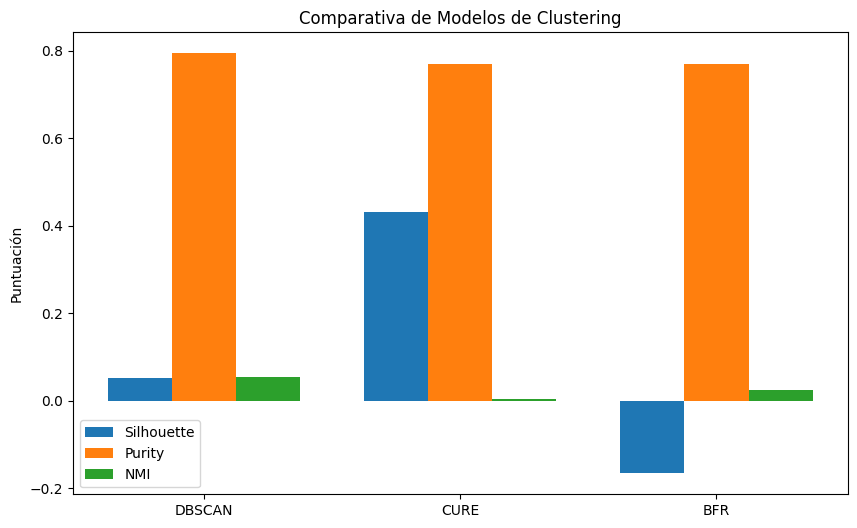

In [33]:
# Evaluar métricas de DBSCAN (ignorar ruido = -1)
dbscan_mask = dbscan.labels_ != -1
if np.sum(dbscan_mask) > 1:
    sil_dbscan = compute_silhouette(X[dbscan_mask], dbscan.labels_[dbscan_mask])
    pur_dbscan = purity_score(y_true[dbscan_mask], dbscan.labels_[dbscan_mask])
    nmi_dbscan = normalized_mutual_information(y_true[dbscan_mask], dbscan.labels_[dbscan_mask])
else:
    sil_dbscan, pur_dbscan, nmi_dbscan = 0, 0, 0

# Guardar métricas de CURE
sil_cure = compute_silhouette(X, cure.labels_)
pur_cure = purity_score(y_true, cure.labels_)
nmi_cure = normalized_mutual_information(y_true, cure.labels_)

# Guardar métricas de BFR
sil_bfr = compute_silhouette(X, bfr.labels_)
pur_bfr = purity_score(y_true, bfr.labels_)
nmi_bfr = normalized_mutual_information(y_true, bfr.labels_)

# Crear Gráfica Comparativa
modelos = ['DBSCAN', 'CURE', 'BFR']
silhouettes = [sil_dbscan, sil_cure, sil_bfr]
purities = [pur_dbscan, pur_cure, pur_bfr]
nmis = [nmi_dbscan, nmi_cure, nmi_bfr]

x = np.arange(len(modelos))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, silhouettes, width, label='Silhouette')
rects2 = ax.bar(x, purities, width, label='Purity')
rects3 = ax.bar(x + width, nmis, width, label='NMI')

ax.set_ylabel('Puntuación')
ax.set_title('Comparativa de Modelos de Clustering')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()

plt.show()

In [38]:
from collections import Counter
import pandas as pd

def perfilar_clusters(labels, nombre_algoritmo):
    print(f"\n==================================================")
    print(f"   PERFILADO SEMÁNTICO - {nombre_algoritmo.upper()}")
    print(f"==================================================")
    
    # Copiar el dataframe de negocios
    df_analisis = top_business_clust.copy()
    df_analisis['cluster'] = labels
    
    unique_labels = sorted(list(set(labels)))
    
    for cluster_id in unique_labels:
        cluster_df = df_analisis[df_analisis['cluster'] == cluster_id]
        total_negocios = len(cluster_df)
        
        if total_negocios == 0:
            continue
            
        avg_stars = cluster_df['stars'].mean()
        avg_reviews = cluster_df['review_count'].mean()
        
        # Encontrar categorías dominantes
        todas_categorias = []
        for cats in cluster_df['categories'].dropna():
            todas_categorias.extend([c.strip() for c in cats.split(',')])
            
        contador_cats = Counter(todas_categorias)
        top_3_cats = [f"{cat} ({count} / {count/total_negocios:.1%})" for cat, count in contador_cats.most_common(3)]
        
        nombre_cluster = f"Clúster {cluster_id}" if cluster_id != -1 else "Ruido / Outliers (-1)"
        print(f"\n--- {nombre_cluster} (Total negocios: {total_negocios}) ---")
        print(f"  * Calificación Promedio (Stars): {avg_stars:.2f}")
        print(f"  * Cantidad Promedio de Reseñas: {avg_reviews:.1f}")
        print(f"  * Categorías Dominantes: {', '.join(top_3_cats)}")

# Ejecutar el perfilado para cada uno de los algoritmos entrenados
perfilar_clusters(km_opt.labels_, "K-Means++")
perfilar_clusters(dbscan.labels_, "DBSCAN")
perfilar_clusters(cure.labels_, "CURE")
perfilar_clusters(bfr.labels_, "BFR")


   PERFILADO SEMÁNTICO - K-MEANS++

--- Clúster 0 (Total negocios: 156) ---
  * Calificación Promedio (Stars): 3.99
  * Cantidad Promedio de Reseñas: 777.0
  * Categorías Dominantes: Restaurants (144 / 92.3%), Event Planning & Services (77 / 49.4%), Nightlife (62 / 39.7%)

--- Clúster 1 (Total negocios: 289) ---
  * Calificación Promedio (Stars): 3.97
  * Cantidad Promedio de Reseñas: 841.8
  * Categorías Dominantes: Restaurants (269 / 93.1%), Nightlife (118 / 40.8%), Bars (117 / 40.5%)

--- Clúster 2 (Total negocios: 93) ---
  * Calificación Promedio (Stars): 3.91
  * Cantidad Promedio de Reseñas: 886.7
  * Categorías Dominantes: Arts & Entertainment (93 / 100.0%), Restaurants (52 / 55.9%), Nightlife (51 / 54.8%)

--- Clúster 3 (Total negocios: 670) ---
  * Calificación Promedio (Stars): 4.00
  * Cantidad Promedio de Reseñas: 790.3
  * Categorías Dominantes: Restaurants (628 / 93.7%), Nightlife (258 / 38.5%), Bars (252 / 37.6%)

--- Clúster 4 (Total negocios: 125) ---
  * Calificació

### Análisis de Complejidad: CURE vs K-Means++ y DBSCAN

* **CURE (Clustering Using Representatives):** El enfoque jerárquico aglomerativo tradicional tiene una complejidad temporal de $O(N^2 \log N)$ y espacial de $O(N^2)$, lo cual es prohibitivo para grandes volúmenes de datos. Sin embargo, nuestra implementación mitiga esto seleccionando una muestra aleatoria (`sample_size`), reduciendo drásticamente la complejidad empírica a costa de una leve pérdida teórica en precisión. Espacialmente, solo requerimos memoria para la muestra y sus representantes. Es muy superior a K-Means al poder encontrar formas no globulares (representantes esparcidos), aunque es más lento.
* **K-Means++:** Su complejidad temporal es lineal $O(I \cdot K \cdot N \cdot D)$ donde $I$ son las iteraciones, $K$ los centroides, $N$ puntos y $D$ dimensiones. Es el más rápido junto con BFR y excelente en memoria $O(K \cdot D)$, pero asume clústeres esféricos.
* **DBSCAN:** Complejidad temporal $O(N^2)$ si no se usa un índice espacial (como un R-Tree, que lo bajaría a $O(N \log N)$). Requiere memoria $O(N)$ y es ideal para detectar outliers y agrupar formas arbitrarias sin definir K a priori, pero es muy sensible a la variación de densidades (parámetro `eps`).